In [1]:
# -*- coding: utf-8 -*-
# test_lead_thresholds.py
# 功能：读取多波段 Sentinel-1 特征栅格，计算 HH/HV 与 HH*HV，并按阈值做分类 + 可视化 + 导出
# 依赖：rasterio, numpy, matplotlib

import os
import numpy as np
import rasterio
from rasterio.plot import reshape_as_image
from rasterio.enums import Resampling
import matplotlib.pyplot as plt

Bands: ('HH', 'HV', 'ANGLE', 'SIC', 'HH_norm', 'HV_norm', 'HH_div_HV', 'HH_minus_HV', 'sum_div_diff')


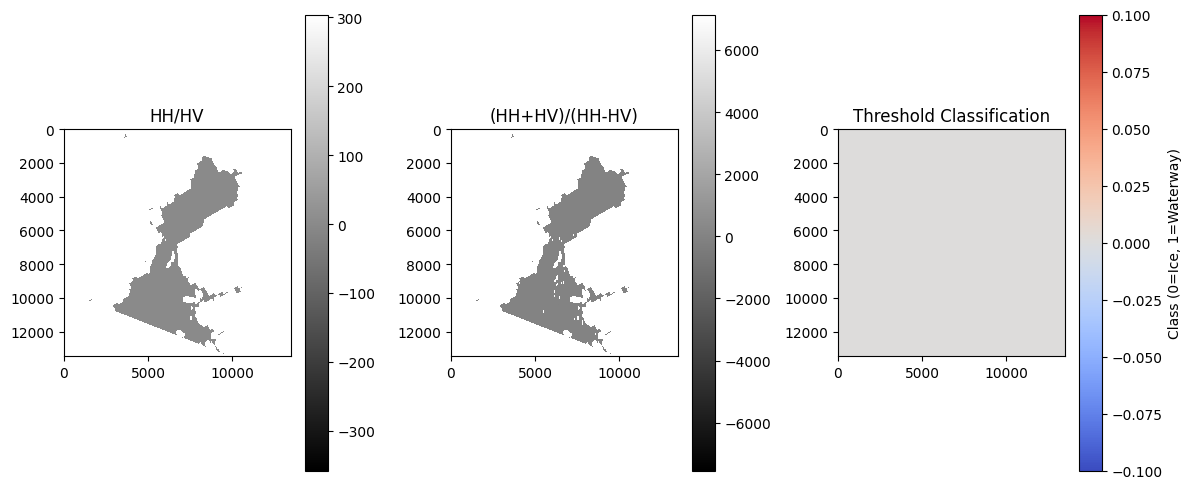

In [14]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# === 参数设置 ===
tif_path = r"F:\NWP\sentinel1 maskbySIC\2023_features\S1A_EW_GRDM_1SDH_20230412T121730_20230412T121835_048063_05C70C_40A9_EW_HH_HV_angle_int16x100_94ae1659_1_bySIC_ice_w10_i15_imax100_float32_with_feats.tif"   # 这里替换成你的tiff文件路径
th1 = 0.7     # HH/HV 阈值
th2 = 1.5     # (HH+HV)/(HH-HV) 阈值

# === 读取数据 ===
with rasterio.open(tif_path) as src:
    band_names = src.descriptions   # 波段名字
    print("Bands:", band_names)

    # 按名字读取需要的波段
    HH_div_HV = src.read(band_names.index("HH_div_HV") + 1)
    sum_div_diff = src.read(band_names.index("sum_div_diff") + 1)

# === 阈值分类 ===
classified = np.zeros_like(HH_div_HV, dtype=np.uint8)
classified[(HH_div_HV < th1) & (sum_div_diff > th2)] = 1   # 1: 水道, 0: 冰

# === 可视化 ===
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.title("HH/HV")
plt.imshow(HH_div_HV, cmap="gray")
plt.colorbar()

plt.subplot(1,3,2)
plt.title("(HH+HV)/(HH-HV)")
plt.imshow(sum_div_diff, cmap="gray")
plt.colorbar()

plt.subplot(1,3,3)
plt.title("Threshold Classification")
plt.imshow(classified, cmap="coolwarm")
plt.colorbar(label="Class (0=Ice, 1=Waterway)")

plt.tight_layout()
plt.show()


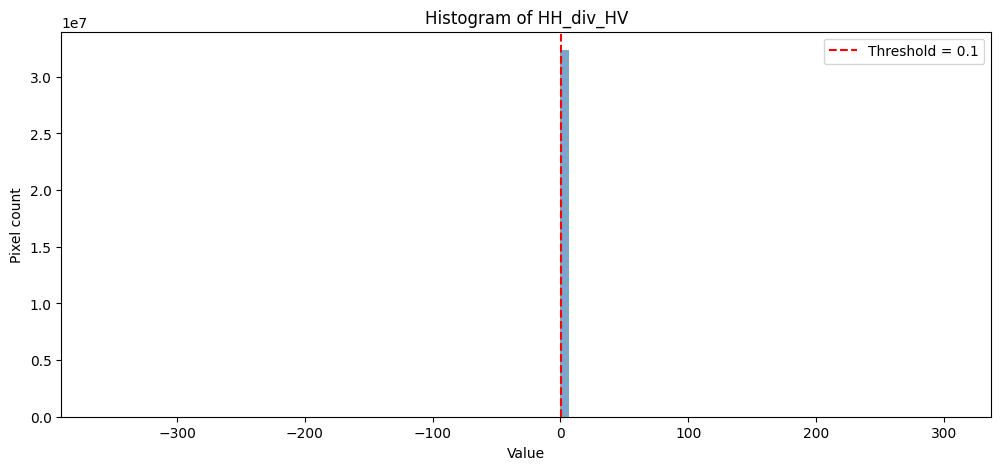

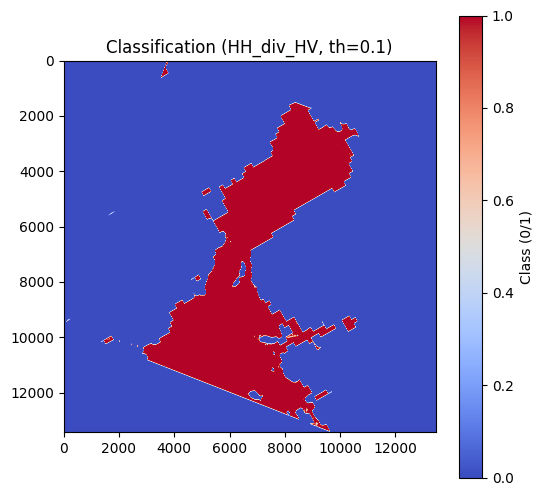

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [20]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

def band_threshold_classification(tif_path, band_name, th=None):
    """
    对指定band进行直方图分析 + 阈值分类
    
    参数:
    tif_path: str, GeoTIFF 文件路径
    band_name: str, 需要分析的波段 (例如 "HH_div_HV")
    th: float or None, 阈值。如果为None，只画直方图，不分类
    """
    # === 打开文件 ===
    with rasterio.open(tif_path) as src:
        band = src.read(1, masked=True)  # 掩膜外会自动处理成 NaN
        band_names = src.descriptions
        if band_name not in band_names:
            raise ValueError(f"波段 {band_name} 不存在, 可用波段: {band_names}")
        band = src.read(band_names.index(band_name) + 1).astype(float)

    # === 掩膜掉无效值 ===
    band = np.where(np.isfinite(band), band, np.nan)

    # === 绘制直方图 ===
    plt.figure(figsize=(12,5))
    plt.hist(band[~np.isnan(band)].ravel(), bins=100, color="steelblue", alpha=0.7)
    plt.title(f"Histogram of {band_name}")
    plt.xlabel("Value")
    plt.ylabel("Pixel count")
    if th is not None:
        plt.axvline(th, color="red", linestyle="--", label=f"Threshold = {th}")
        plt.legend()
    plt.show()

    # === 如果给了阈值, 输出分类结果 ===
    if th is not None:
        classified = np.zeros_like(band, dtype=np.uint8)
        classified[band > th] = 1   # 1: 类别A, 0: 类别B
        plt.figure(figsize=(6,6))
        plt.title(f"Classification ({band_name}, th={th})")
        plt.imshow(classified, cmap="coolwarm")
        plt.colorbar(label="Class (0/1)")
        plt.show()
        return classified
    
    return None


tif_path = r"F:\NWP\sentinel1 maskbySIC\2023_features\S1A_EW_GRDM_1SDH_20230412T121730_20230412T121835_048063_05C70C_40A9_EW_HH_HV_angle_int16x100_94ae1659_1_bySIC_ice_w10_i15_imax100_float32_with_feats.tif"   # 这里替换成你的tiff文件路径
# 只看分布，不分类
band_threshold_classification(tif_path, band_name="HH_div_HV", th = 0.1)
